# Rescaling simulation results

In the Stokes regime, permeability is purely a geometric property — it depends only on the pore structure, not on the fluid. This means a single LBM simulation can be reinterpreted for different voxel sizes without rerunning the solver. Velocity and pressure fields can also be converted to physical units for a given fluid.

Poromics exposes this via `PermeabilityResult.rescale()`.

> **Note:** Tortuosity and effective diffusivity are already dimensionless ratios ($\tau$, $D_\text{eff}/D_0$), so `TortuosityResult` does not need a `rescale` method — its results are valid regardless of the physical diffusivity or voxel size.

In [1]:
import numpy as np
import porespy as ps
import poromics

## Run the simulation once

We simulate flow through a synthetic porous medium using water at 20 °C ($\nu = 10^{-6}$ m²/s) and a voxel size of 1 µm.

In [2]:
im = ps.generators.blobs(shape=[100, 100, 1], porosity=0.6, blobiness=0.5, seed=42)
result = poromics.permeability_lbm(im, axis=1, nu=1e-6, voxel_size=1e-6)
print(result)

12:31:14 | WARNING  | poromics._metrics:permeability_lbm:772 - Trimmed 972 non-percolating pore voxels from the image.
[I 04/16/26 12:31:14.933 64600984] [shell.py:_shell_pop_print@23] Graphical python shell detected, using wrapped sys.stdout


[Taichi] version 1.7.4, llvm 15.0.7, commit b4b956fd, osx, python 3.12.9


[Taichi] Starting on arch=metal


Flow:   0%|          | 0.0% ·  · 00:00

PermeabilityResult:
  axis       = 1
  porosity   = 0.4951
  k          = 2.8267e-13 m² (286.42 mD)
  u_darcy    = 3.3921e-04 m/s
  u_pore     = 6.8513e-04 m/s
  converged  = True (5501 iters)


## Rescale to a different voxel size

The same pore geometry imaged at 5 µm/voxel instead of 1 µm/voxel represents a physically larger sample. Since $k \propto \Delta x^2$, permeability scales with the square of the voxel size, while the pore structure (and therefore the lattice-unit permeability) stays the same.

In [3]:
r_5um = result.rescale(voxel_size=5e-6, nu=1e-6)
print(f"Original (1 µm):  k = {result.k:.4e} m²")
print(f"Rescaled (5 µm):  k = {r_5um.k:.4e} m²")
print(f"Ratio: {r_5um.k / result.k:.1f}x  (expected 25x)")

Original (1 µm):  k = 2.8267e-13 m²
Rescaled (5 µm):  k = 7.0668e-12 m²
Ratio: 25.0x  (expected 25x)


## Permeability is independent of the fluid

Permeability $k$ is a property of the geometry alone. Changing the fluid viscosity does not affect $k$ — only the velocity and pressure fields change.

In [4]:
r_glycerol = result.rescale(voxel_size=1e-6, nu=1e-3, rho=1260)
r_water = result.rescale(voxel_size=1e-6, nu=1e-6, rho=1000)

print(f"Water (nu=1e-6):    k = {r_water.k:.4e} m²")
print(f"Glycerol (nu=1e-3): k = {r_glycerol.k:.4e} m²")
print(f"Same k? {np.isclose(r_water.k, r_glycerol.k)}")

Water (nu=1e-6):    k = 2.8267e-13 m²
Glycerol (nu=1e-3): k = 2.8267e-13 m²
Same k? True


> **Streamlines are also invariant.** Because the Stokes equations are linear and scale-invariant, rescaling multiplies every velocity vector by the same scalar — magnitudes change but directions don't. The flow pattern through a given pore geometry is identical regardless of the physical voxel size, fluid, or driving pressure. This is the fundamental reason why permeability is a purely geometric property. (This invariance breaks down at higher Reynolds numbers, where inertial effects introduce Re-dependent features like flow separation.)

## Pressure field comparison

When `rho` is provided, `rescale` converts the lattice-unit density field to gauge pressure in Pa. Different fluids (and thus different unit conversions) yield different physical pressure magnitudes for the same underlying lattice simulation.

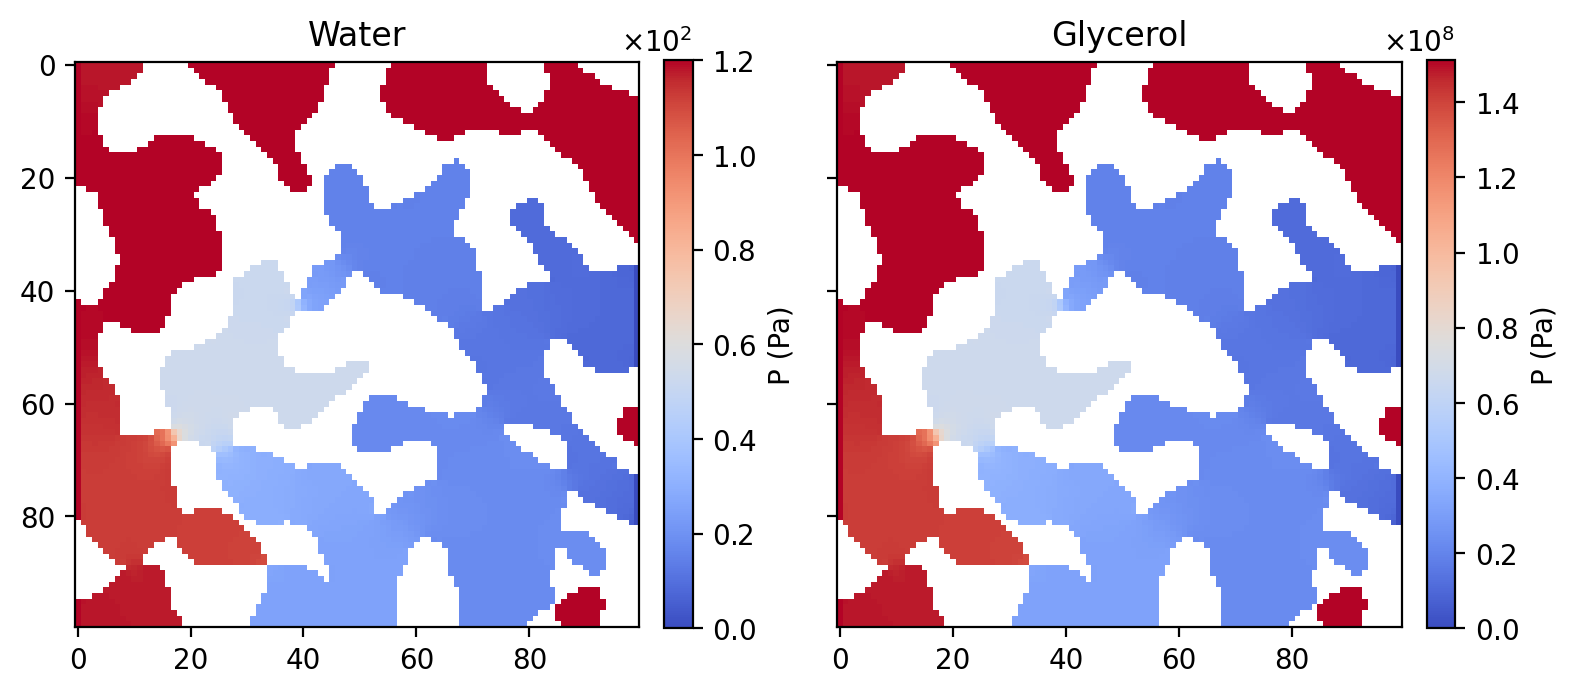

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), sharey=True)
for ax, r, label in zip(axes, [r_water, r_glycerol], ["Water", "Glycerol"]):
    p = r.pressure[:, :, 0].astype(float)
    p[~im[:, :, 0]] = np.nan
    mappable = ax.imshow(p, cmap="coolwarm", interpolation="nearest")
    ax.set_title(label)
    cb = fig.colorbar(mappable, ax=ax, fraction=0.046, pad=0.04, label="P (Pa)")
    cb.ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    cb.ax.ticklabel_format(style="scientific", scilimits=(-1, 1))
fig.tight_layout()

## Rescaling is chainable

A rescaled result retains the lattice-unit data, so it can be rescaled again. This round-trips exactly back to the original.

In [6]:
r_roundtrip = r_glycerol.rescale(voxel_size=1e-6, nu=1e-6)
print(f"Original k:    {result.k:.6e} m²")
print(f"Round-trip k:  {r_roundtrip.k:.6e} m²")
print(f"Match: {np.isclose(result.k, r_roundtrip.k)}")

Original k:    2.826718e-13 m²
Round-trip k:  2.826718e-13 m²
Match: True
